In [1]:
import gc

# Clear GPU memory
import cupy as cp
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

# Clear CPU memory
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [4]:
# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 0.25   # Total time
force_backend = "cuda12x"  # Force GPU

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}



# waveform_class = FastKerrEccentricEquatorialFlux
# waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
#                              amplitude_kwargs=amplitude_kwargs,
#                              Ylm_kwargs=Ylm_kwargs,
#                              sum_kwargs=sum_kwargs,
#                              use_gpu=use_gpu)

 
#waveform generator setup
# waveform_generator = GenerateEMRIWaveform
# waveform_generator_kwargs = dict(frame='detector')

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)

Creating GenerateEMRIWaveform class...


In [5]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [6]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [7]:
waveform = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,  T=T, dt=dt)

In [8]:
import pickle
with open('sampling_test/cov_matrix_intrinsic_new.pkl', 'rb') as f:
    cov_mat = pickle.load(f)

In [9]:
pars_list = [np.log10(m1), np.log10(m2), a, p0, e0]


In [10]:
Fisher = np.linalg.inv(cov_mat)
sigma1D = 1/np.sqrt(Fisher[2, 2])
sigma1D

2.077575257344272e-07

In [11]:
sigmas = []
for i in range(len(pars_list)):
    sigmas.append(1/np.sqrt(Fisher[i, i]))

In [12]:
sigmas

[1.7836974728156583e-08,
 9.93609980858465e-08,
 2.077575257344272e-07,
 1.8736100138734407e-07,
 7.609743177715428e-08]

In [56]:
priors = []
for i in range(len(pars_list)):
    print(f"Parameter: {pars_list[i]}, Sigma: {sigmas[i]}")
    # set 3sig prior range
    prior_min = pars_list[i] - 100*sigmas[i]
    prior_max = pars_list[i] + 100*sigmas[i]
    print(f"15-sigma prior range: [{prior_min}, {prior_max}]")
    priors.append([prior_min, prior_max])

Parameter: 6.0, Sigma: 1.7836974728156583e-08
15-sigma prior range: [5.999998216302528, 6.000001783697472]
Parameter: 1.4771212547196624, Sigma: 9.93609980858465e-08
15-sigma prior range: [1.477111318619854, 1.4771311908194709]
Parameter: 0.7, Sigma: 2.077575257344272e-07
15-sigma prior range: [0.6999792242474265, 0.7000207757525734]
Parameter: 7.5, Sigma: 1.8736100138734407e-07
15-sigma prior range: [7.499981263899861, 7.500018736100139]
Parameter: 0.4, Sigma: 7.609743177715428e-08
15-sigma prior range: [0.3999923902568223, 0.40000760974317773]


In [57]:
priors

[[5.999998216302528, 6.000001783697472],
 [1.477111318619854, 1.4771311908194709],
 [0.6999792242474265, 0.7000207757525734],
 [7.499981263899861, 7.500018736100139],
 [0.3999923902568223, 0.40000760974317773]]

In [58]:
def loglike(params):
    logm1, logm2, a, p0, e0 = params
    m1 = 10**logm1
    m2 = 10**logm2
    phiK = phiS + np.pi/3

    htemp = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
    
  
    res = waveform - htemp

    res_f = gwf.freq_wave(res)
    inner_res = gwf.inner(res_f, res_f)

    calc_loglike = - 0.5 * inner_res
        

    return calc_loglike


In [59]:
# x = np.linspace(a - 2*sigma1D, a + 2*sigma1D, 50)
x = np.linspace(priors[0][0], priors[0][1], 50)

In [60]:
loglike_vals = []
for val in x:
    param = [val, np.log10(m2), a, p0, e0]
    calc_loglike = loglike(param)
    print(calc_loglike)
    loglike_vals.append(calc_loglike)


-4207.480257511251
-3922.6990297567436
-3642.2437470497885
-3366.8757925200134
-3097.3607189399568
-2834.465009269198
-2578.952733457514
-2331.582009751299
-2093.101389274324
-1864.2461157309106
-1645.7343123719193
-1438.2631573152603
-1242.5050071830026
-1059.1035894311722
-888.6702140979762
-731.7801202128547
-588.9689338296465
-460.7293023302239
-347.50775452111486
-249.7017838483457
-167.65723393737943
-101.66597700396653
-51.96394615302193
-18.729522540159667
-2.0823095161114753
-2.082308821379216
-18.729503726711556
-51.96385912345138
-101.66573852113933
-167.65672824938574
-249.7008626182305
-347.50623861186904
-460.7269815367481
-588.9655686531611
-731.775442251556
-888.6639280704023
-1059.0953738518658
-1242.4945156450956
-1438.2500198161838
-1645.7181366150724
-1864.2264893301397
-2093.0778802095915
-2331.554168788343
-2578.9200940619935
-2834.427090606061
-3097.31702663888
-3366.8258199475927
-3642.186977379015
-3922.634937116195
-4207.408307958965


In [61]:
# like_vals = [np.exp(ll.get()) for ll in loglike_vals]
# like_vals

In [62]:
import loglikebasic

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
loglike_obj = loglikebasic.LogLike(params_star, waveform_gen_comb, gwf, M_init=5, verbose=True, waveform_gen_sep=waveform_gen_sep, noise_weighted=True)
def fstat(params):
    logm1, logm2, a, p0, e0 = params
    m1 = 10**logm1
    m2 = 10**logm2

    loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
    
    return loglike

Delta_T for mode selection: 1577.9074881772797 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, -1) with power 9.974262862349239e+40
Considering mode 1 / 5 : (2, -2, 0) with power 6.642561846697805e+40
 - Overlap with selected mode 0: 1.3756139121950971e-05
Considering mode 2 / 5 : (2, -2, 1) with power 1.6104220655488966e+40
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 4.1047111851760084e-06
Considering mode 3 / 5 : (3, -3, -1) with power 1.037045153189791e+40
 - Overlap with selected mode 0: 1.0738383748208835e-05
 - Overlap with selected mode 1: 2.5018652016809717e-06
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (3, -3, 1) with power 8.643406638461486e+39
 - Overlap with selected mode 0: 4.2113409203417295e-06
 - Overlap with selected mode 1: 1.0762951337404438e-06
 - Overlap with selected mode 2: 2.0388858636726997e-06
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, -1)], [(2, -2, 0)], [(2, 

In [63]:
f_vals = []
for val in x:
    param = [val, np.log10(m2), a, p0, e0]
    calc_fstat = fstat(param)
    print(calc_fstat)
    f_vals.append(calc_fstat)


Waveform amplitudes:
  Mode 0: max(|h|) = 7.052282306164832e-22, <hf|hf> = 4363.900410164869, rho = 66.0598244787622
  Mode 1: max(|h|) = 7.113714530071045e-22, <hf|hf> = 1728.9147764680083, rho = 41.580220976661586
  Mode 2: max(|h|) = 5.22262832288996e-22, <hf|hf> = 231.78274928469716, rho = 15.22441293727601
  Mode 3: max(|h|) = 2.2681549706839757e-22, <hf|hf> = 281.09203335214323, rho = 16.76579951425351
  Mode 4: max(|h|) = 1.882040694078572e-22, <hf|hf> = 198.00027135507437, rho = 14.071256921649692
Individual rho values: [66.05982448 41.58022098 15.22441294 16.76579951 14.07125692]
Max rho: 66.0598244787622, Min rho: 14.071256921649692
Dominant mode rho (first): 66.0598244787622
Actually dominant mode index: 0
Actually dominant mode rho: 66.0598244787622
Mode 0 rho: 66.0598244787622
Xdotrho: (2108.195148962124+0j)
Using actually dominant mode 0 for rho_dom_M: 66.0598244787622
beta 0.0034351817608584048
rho_dom_M: 66.0598244787622, rho_tot: 82.48448484790816, beta: 0.003435181760

In [64]:
# ef_vals = [np.exp(f) for f in f_vals]
# ef_vals

In [65]:
f_vals_new = [f-82 for f in f_vals]

In [66]:
loglike_vals_new = [ll.get() for ll in loglike_vals]

In [67]:
data_f = gwf.freq_wave(waveform)
X_vals = []
for val in x:
    param = [val, np.log10(m2), a, p0, e0]
    m1 = 10**param[0]
    m2 = 10**param[1]
    htemp = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
    
    htemp_f = gwf.freq_wave(htemp)
    inner_data_htemp = gwf.inner(data_f, htemp_f)
    print('<x|h>:', inner_data_htemp)
    opt_SNR_htemp = np.sqrt(gwf.inner(htemp_f, htemp_f))
    print('sqrt(<h|h>)', opt_SNR_htemp)
    X_calc = inner_data_htemp / (opt_SNR_htemp)
    print('X:', X_calc)
    X_vals.append(X_calc)

<x|h>: 7335.8617002888395
sqrt(<h|h>) 107.44043002763999
X: 68.2784097048162
<x|h>: 7620.63776920103
sqrt(<h|h>) 107.44038201179094
X: 70.92898988729127
<x|h>: 7901.08792253214
sqrt(<h|h>) 107.44033427017936
X: 73.53930882850138
<x|h>: 8176.450784064279
sqrt(<h|h>) 107.44028686713662
X: 76.10227990339867
<x|h>: 8445.960807896867
sqrt(<h|h>) 107.44023986662386
X: 78.6107776600431
<x|h>: 8708.851517889256
sqrt(<h|h>) 107.44019333210886
X: 81.05766797132695
<x|h>: 8964.358850847377
sqrt(<h|h>) 107.44014732647105
X: 83.4358391524538
<x|h>: 9211.724695205861
sqrt(<h|h>) 107.44010191189481
X: 85.73823489817465
<x|h>: 9450.200506435
sqrt(<h|h>) 107.4400571497552
X: 87.95788793431902
<x|h>: 9679.05104732704
sqrt(<h|h>) 107.4400131005201
X: 90.08795483179428
<x|h>: 9897.55820101605
sqrt(<h|h>) 107.43996982361804
X: 92.12175149774023
<x|h>: 10105.02479564604
sqrt(<h|h>) 107.43992737733316
X: 94.05278877522696
<x|h>: 10300.778480716746
sqrt(<h|h>) 107.43988581864522
X: 95.87480852412763
<x|h>: 10

In [86]:
X_vals_new = [X.get()-109 for X in X_vals]

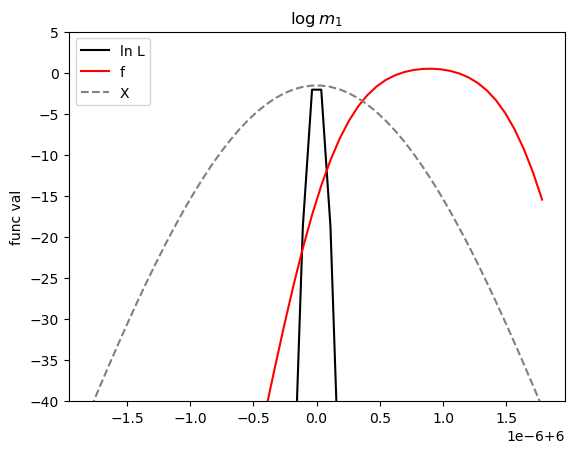

In [90]:
# NOTE: do not normalize
plt.plot(x, loglike_vals_new, c='k', label='ln L')
plt.plot(x, f_vals_new, c='r',label=r'f')
plt.plot(x, X_vals_new, c='grey',linestyle='dashed', label=r'X')
plt.ylim(-40,5)
plt.legend()
plt.ylabel(r'func val')
plt.title(r'$\log m_1$')
plt.show()

# Recalculate f_vals!!

Say I have the same 5 mode templates [(2, -2, -1), (2, -2, 0), (2, -2, 1), (3, -3, -1), (3, -3, 1)]

In [89]:
# Generate those 5 modes
sel_modes = [(2, -2, -1), (2, -2, 0), (2, -2, 1), (3, -3, -1), (3, -3, 1)]


In [ ]:
# BUT THIS IS in the true point. so have to generate for each param point
waveforms = waveform_gen_sep(
    m1, m2, a, p0, e0, xI0, dist, 
    qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, 
    dt=dt,
    T=T,
    mode_selection=sel_modes, 
    include_minus_mkn=False,
)


In [97]:
index_map = waveform_gen_sep.waveform_generator.index_map
index_map

{(2, 0, -55): 0,
 (2, 0, -54): 1,
 (2, 0, -53): 2,
 (2, 0, -52): 3,
 (2, 0, -51): 4,
 (2, 0, -50): 5,
 (2, 0, -49): 6,
 (2, 0, -48): 7,
 (2, 0, -47): 8,
 (2, 0, -46): 9,
 (2, 0, -45): 10,
 (2, 0, -44): 11,
 (2, 0, -43): 12,
 (2, 0, -42): 13,
 (2, 0, -41): 14,
 (2, 0, -40): 15,
 (2, 0, -39): 16,
 (2, 0, -38): 17,
 (2, 0, -37): 18,
 (2, 0, -36): 19,
 (2, 0, -35): 20,
 (2, 0, -34): 21,
 (2, 0, -33): 22,
 (2, 0, -32): 23,
 (2, 0, -31): 24,
 (2, 0, -30): 25,
 (2, 0, -29): 26,
 (2, 0, -28): 27,
 (2, 0, -27): 28,
 (2, 0, -26): 29,
 (2, 0, -25): 30,
 (2, 0, -24): 31,
 (2, 0, -23): 32,
 (2, 0, -22): 33,
 (2, 0, -21): 34,
 (2, 0, -20): 35,
 (2, 0, -19): 36,
 (2, 0, -18): 37,
 (2, 0, -17): 38,
 (2, 0, -16): 39,
 (2, 0, -15): 40,
 (2, 0, -14): 41,
 (2, 0, -13): 42,
 (2, 0, -12): 43,
 (2, 0, -11): 44,
 (2, 0, -10): 45,
 (2, 0, -9): 46,
 (2, 0, -8): 47,
 (2, 0, -7): 48,
 (2, 0, -6): 49,
 (2, 0, -5): 50,
 (2, 0, -4): 51,
 (2, 0, -3): 52,
 (2, 0, -2): 53,
 (2, 0, -1): 54,
 (2, 0, 0): 55,
 (2, 0, 1): 5

In [98]:
sorted_indices = sorted(range(len(sel_modes)), 
                    key=lambda i: (index_map[sel_modes[i]] % 1000 // 100, 
                                    -(index_map[sel_modes[i]] % 100)))
waveforms = waveforms[:, sorted_indices]    

In [105]:
len(waveforms.T)

5

In [122]:
# Calculate rho_M manually
rho_M = []
for wave in waveforms.T:
    wave_f = gwf.freq_wave(wave)
    calc_SNR = np.sqrt(gwf.inner(wave_f, wave_f))
    print('Calculated SNR:', calc_SNR)
    rho_M.append(calc_SNR.item())

Calculated SNR: 66.05896735849426
Calculated SNR: 41.57867871291787
Calculated SNR: 15.223196168566117
Calculated SNR: 16.765511603183416
Calculated SNR: 14.070844284416852


In [123]:
rho_M

[66.05896735849426,
 41.57867871291787,
 15.223196168566117,
 16.765511603183416,
 14.070844284416852]

In [130]:
waveforms_per_param = []
for val in x:
    waveforms = waveform_gen_sep(
        10**val, m2, a, p0, e0, xI0, dist, 
        qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, 
        dt=dt,
        T=T,
        mode_selection=sel_modes, 
        include_minus_mkn=False,
    )
    sorted_indices = sorted(range(len(sel_modes)), 
                    key=lambda i: (index_map[sel_modes[i]] % 1000 // 100, 
                                    -(index_map[sel_modes[i]] % 100)))
    waveforms = waveforms[:, sorted_indices]  
    waveforms_per_param.append(waveforms)


In [ ]:
ex_waveforms = waveforms_per_param[1].T

In [141]:
for val, idx in enumerate(x):
    print(val, idx)

0 5.999998216302528
1 5.9999982891065065
2 5.999998361910484
3 5.999998434714463
4 5.999998507518441
5 5.99999858032242
6 5.999998653126398
7 5.999998725930377
8 5.999998798734356
9 5.999998871538334
10 5.9999989443423125
11 5.9999990171462905
12 5.999999089950269
13 5.999999162754247
14 5.999999235558226
15 5.999999308362205
16 5.999999381166183
17 5.999999453970162
18 5.99999952677414
19 5.999999599578119
20 5.9999996723820965
21 5.999999745186075
22 5.999999817990054
23 5.999999890794032
24 5.999999963598011
25 6.000000036401989
26 6.000000109205968
27 6.000000182009946
28 6.000000254813925
29 6.0000003276179035
30 6.000000400421881
31 6.00000047322586
32 6.000000546029838
33 6.000000618833817
34 6.000000691637795
35 6.000000764441774
36 6.000000837245753
37 6.000000910049731
38 6.0000009828537095
39 6.0000010556576875
40 6.000001128461666
41 6.000001201265644
42 6.000001274069623
43 6.000001346873602
44 6.00000141967758
45 6.000001492481559
46 6.000001565285537
47 6.000001638089516

In [142]:
# Calculate rho_M manually
# NOTE: not efficient but fuck it lah
rho_M = []
for idx, val in enumerate(x):
    val_waveforms = waveforms_per_param[idx].T
    rho_M_val = []
    for wave in val_waveforms:
        wave_f = gwf.freq_wave(wave)
        calc_SNR = np.sqrt(gwf.inner(wave_f, wave_f))
        print('Calculated SNR:', calc_SNR)
        rho_M_val.append(calc_SNR.item())
    rho_M.append(rho_M_val)

Calculated SNR: 66.0598244787622
Calculated SNR: 41.580220976661586
Calculated SNR: 15.22441293727601
Calculated SNR: 16.76579951425351
Calculated SNR: 14.071256921649692
Calculated SNR: 66.05979143467347
Calculated SNR: 41.58017559461484
Calculated SNR: 15.224354879246771
Calculated SNR: 16.765794528815913
Calculated SNR: 14.07125320772541
Calculated SNR: 66.0597584198305
Calculated SNR: 41.58013055602747
Calculated SNR: 15.224298058343642
Calculated SNR: 16.765789645787304
Calculated SNR: 14.071249295494288
Calculated SNR: 66.05972549947077
Calculated SNR: 41.58008589328556
Calculated SNR: 15.224242509484457
Calculated SNR: 16.765784855923272
Calculated SNR: 14.071245173510192
Calculated SNR: 66.05969273844552
Calculated SNR: 41.5800416377694
Calculated SNR: 15.22418826560512
Calculated SNR: 16.765780149225733
Calculated SNR: 14.071240831224197
Calculated SNR: 66.05966020094984
Calculated SNR: 41.57999781976448
Calculated SNR: 15.224135357601906
Calculated SNR: 16.765775515023357
Cal

In [145]:
X_m_tot = []
for idx, val in enumerate(x):
    val_waveforms = waveforms_per_param[idx].T
    X_val = []
    for mode_idx, wave in enumerate(val_waveforms):
        wave_f = gwf.freq_wave(wave)
        overlap = gwf.inner(data_f, wave_f)
        rho_m = rho_M[idx][mode_idx]
        X_m = overlap/rho_m 
        X_val.append(X_m.item())
    X_m_tot.append(X_val)


In [154]:
X_m_tot_array = np.array(X_m_tot)
X_m_tot_array

array([[44.13774104, 26.65517453, 10.89690459,  4.6026855 ,  8.54250654],
       [45.69746013, 27.74292054, 11.22257329,  5.39245483,  8.95879781],
       [47.22123024, 28.80021235, 11.53762831,  6.18408192,  9.3661763 ],
       [48.70571034, 29.82528701, 11.84170843,  6.97402567,  9.76367111],
       [50.1476297 , 30.81643166, 12.13446478,  7.7587148 , 10.15033045],
       [51.54379697, 31.7719869 , 12.41556127,  8.53456748, 10.52522445],
       [52.8911089 , 32.69034992, 12.68467502,  9.29801104, 10.88744781],
       [54.186559  , 33.56997761, 12.94149674, 10.04550188, 11.23612253],
       [55.42724579, 34.4093895 , 13.18573111, 10.77354517, 11.57040039],
       [56.61038088, 35.20717068, 13.41709715, 11.47871441, 11.88946554],
       [57.7332968 , 35.96197449, 13.63532859, 12.15767079, 12.19253684],
       [58.79345431, 36.67252511, 13.84017414, 12.8071819 , 12.47887018],
       [59.78844962, 37.33762008, 14.03139788, 13.42414017, 12.74776068],
       [60.71602097, 37.95613255, 14.2

In [152]:
rho_M_array = np.array(rho_M)
rho_M_array

array([[66.05982448, 41.58022098, 15.22441294, 16.76579951, 14.07125692],
       [66.05979143, 41.58017559, 15.22435488, 16.76579453, 14.07125321],
       [66.05975842, 41.58013056, 15.22429806, 16.76578965, 14.0712493 ],
       [66.0597255 , 41.58008589, 15.22424251, 16.76578486, 14.07124517],
       [66.05969274, 41.58004164, 15.22418827, 16.76578015, 14.07124083],
       [66.0596602 , 41.57999782, 15.22413536, 16.76577552, 14.07123626],
       [66.05962795, 41.57995447, 15.22408381, 16.76577094, 14.07123145],
       [66.05959605, 41.57991161, 15.22403366, 16.76576642, 14.07122639],
       [66.05956456, 41.57986928, 15.22398493, 16.76576193, 14.07122108],
       [66.05953353, 41.57982749, 15.22393763, 16.76575747, 14.07121551],
       [66.05950303, 41.57978627, 15.22389179, 16.76575302, 14.07120968],
       [66.05947312, 41.57974564, 15.22384743, 16.76574857, 14.07120359],
       [66.05944383, 41.57970562, 15.22380455, 16.76574411, 14.07119722],
       [66.05941523, 41.57966624, 15.2

In [157]:
chi_sq_tot = []
for idx in range(len(x)):
    X_theta = X_m_tot_array[idx, :]
    rho_theta = rho_M_array[idx, :]

    diff = X_theta-rho_theta
    chi_sq = np.sum(diff**2)
    print(chi_sq)
    chi_sq_tot.append(chi_sq)

900.5705056685746
777.5984755934176
665.9182377816306
565.2124179973084
475.0962056668482
395.1224372554951
324.7874761448794
263.5377956649664
210.77722705719307
165.87477038859458
128.1728859819496
96.9961701525099
71.66029310608366
51.48109843924028
35.783730817146385
23.911679152374525
15.235603618766378
9.161827228191507
5.140371985093265
2.67242300574978
1.3171152729863103
0.6975428655292427
0.505903865965637
0.5077048450960749
0.5449632268042118
0.5383601542801475
0.4883121242845634
0.47494571663197016
0.6569761017336113
1.26950635916794
2.6207806279403014
5.0879397338747445
9.111842008977646
15.191026514583722
23.874906097735156
35.756291304931295
51.46335060027537
71.65112400827154
96.9927100235917
128.170244867468
165.86580555186532
210.75234820034032
263.4848152301097
324.69150967006186
394.9658595373905
474.85866503587073
564.870911333099
665.4472472315316
776.9701657913872
899.7549796073855


In [161]:
beta_vals = []
for idx in range(len(x)):
    X_theta = X_m_tot_array[idx, :]
    rho_theta = rho_M_array[idx, :]

    rho_dom = rho_theta[0]
    # rho_total is the actual SNR calculation 
    # we only use 5 modes so its way off. 
    # need to calc based on the full waveform for accuracy
    rho_total = np.sqrt(np.sum(rho_theta**2))
    alpha = rho_dom / rho_total

    num = 2*np.log(alpha*rho_total)
    denom = (1-alpha**2)*rho_total**2
    beta = num/denom
    print(beta)
    beta_vals.append(beta)


0.0034351817608584048
0.0034351895360990726
0.003435197221494102
0.0034352048134534577
0.003435212308585052
0.0034352197036987193
0.0034352269958080094
0.003435234182133028
0.003435241260101448
0.0034352482273498335
0.003435255081724665
0.0034352618212819905
0.003435268444288052
0.0034352749492182026
0.003435281334756841
0.003435287599795877
0.0034352937434337393
0.003435299764974167
0.0034353056639240547
0.0034353114399923316
0.0034353170930874885
0.0034353226233161554
0.003435328030980625
0.0034353333165769466
0.003435338480792999
0.0034353435245059872
0.0034353484487807187
0.003435353254867138
0.003435357944198608
0.003435362518389536
0.003435366979233452
0.003435371328701241
0.0034353755689387135
0.0034353797022651567
0.003435383731170875
0.0034353876583157095
0.003435391486526665
0.0034353952187960307
0.003435398858279442
0.00343540240829338
0.0034354058723132298
0.003435409253970542
0.0034354125570507663
0.003435415785490165
0.0034354189433730095
0.0034354220349283623
0.003435425

In [162]:
X_vals

[array(68.2784097),
 array(70.92898989),
 array(73.53930883),
 array(76.1022799),
 array(78.61077766),
 array(81.05766797),
 array(83.43583915),
 array(85.7382349),
 array(87.95788793),
 array(90.08795483),
 array(92.1217515),
 array(94.05278878),
 array(95.87480852),
 array(97.58181906),
 array(99.16813043),
 array(100.62838839),
 array(101.9576074),
 array(103.15120195),
 array(104.20501578),
 array(105.11534902),
 array(105.87898254),
 array(106.49319957),
 array(106.955804),
 array(107.26513539),
 array(107.42008038),
 array(107.42008038),
 array(107.26513544),
 array(106.95580423),
 array(106.49320021),
 array(105.8789839),
 array(105.1153515),
 array(104.20501988),
 array(103.15120828),
 array(101.95761664),
 array(100.62840134),
 array(99.16814799),
 array(97.58184223),
 array(95.87483842),
 array(94.05282663),
 array(92.12179866),
 array(90.08801277),
 array(87.95795823),
 array(85.73831926),
 array(83.43593942),
 array(81.0577861),
 array(78.61091573),
 array(76.10244013),
 ar

In [163]:
f_vals_fix = []
for idx in range(len(x)):
    X_theta_tot = X_vals[idx].get()
    beta_theta = beta_vals[idx]
    chi_sq_theta = chi_sq_tot[idx]
    f_theta = X_theta_tot * np.exp(-0.5*beta_theta*chi_sq_theta)
    print(f_theta)
    f_vals_fix.append(f_theta)

14.538232727360011
18.654364885236543
23.43052916421756
28.82571913819869
34.76046381481926
41.12000162653011
47.76143860284904
54.524048013558904
61.2413637938358
67.75348947138377
73.91810631973986
79.6189864212958
84.77130412158282
89.32356439347637
93.25643885785631
96.57912892006308
99.32404892478937
101.54063675127337
103.2890005393229
104.63394349242179
105.63971752171274
106.36568196521527
106.8629026818018
107.171633704785
107.31957507768853
107.32079214801743
107.17520332998454
106.86858493393397
106.37309318232323
105.64835495951638
104.64322019039504
103.29829002162292
101.5493262686418
99.33159838128934
96.58513093500065
93.26067348869864
89.32604075536688
84.77228062947805
79.61896253202224
73.91778159869153
67.75369052157761
61.242945621952764
54.52778219251397
47.767905261218715
41.129503513826805
34.772978530036355
28.840899049416382
23.447749585640885
18.672811543438286
14.557011835290274


In [170]:
f_vals_fix_new = [f-109 for f in f_vals_fix]
f_vals_fix_new

[-94.46176727263999,
 -90.34563511476345,
 -85.56947083578244,
 -80.17428086180131,
 -74.23953618518074,
 -67.87999837346989,
 -61.23856139715096,
 -54.475951986441096,
 -47.7586362061642,
 -41.24651052861623,
 -35.08189368026014,
 -29.3810135787042,
 -24.228695878417184,
 -19.676435606523626,
 -15.74356114214369,
 -12.420871079936916,
 -9.675951075210634,
 -7.459363248726632,
 -5.710999460677101,
 -4.366056507578207,
 -3.3602824782872602,
 -2.6343180347847266,
 -2.137097318198201,
 -1.8283662952150053,
 -1.6804249223114738,
 -1.679207851982568,
 -1.8247966700154592,
 -2.131415066066026,
 -2.626906817676769,
 -3.3516450404836178,
 -4.356779809604959,
 -5.701709978377082,
 -7.450673731358194,
 -9.66840161871066,
 -12.414869064999351,
 -15.739326511301357,
 -19.673959244633124,
 -24.227719370521953,
 -29.381037467977762,
 -35.08221840130847,
 -41.24630947842239,
 -47.757054378047236,
 -54.47221780748603,
 -61.232094738781285,
 -67.8704964861732,
 -74.22702146996365,
 -80.15910095058362,


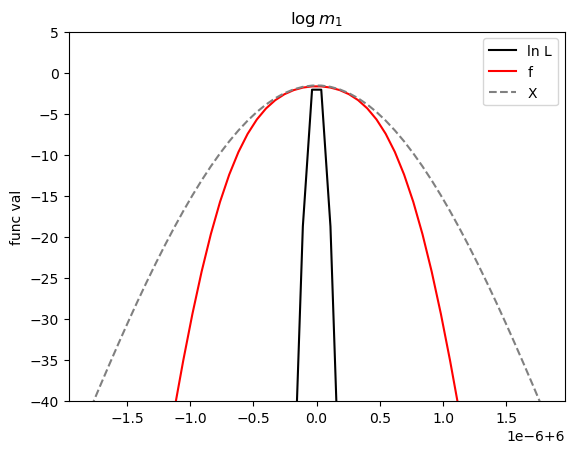

In [ ]:
# NOTE: do not normalize
plt.plot(x, loglike_vals_new, c='k', label='ln L')
plt.plot(x, f_vals_fix_new, c='r',label=r'f')
plt.plot(x, X_vals_new, c='grey',linestyle='dashed', label=r'X')
plt.ylim(-40,5)
plt.legend()
plt.ylabel(r'func val')
plt.title(r'$\log m_1$')
plt.show()

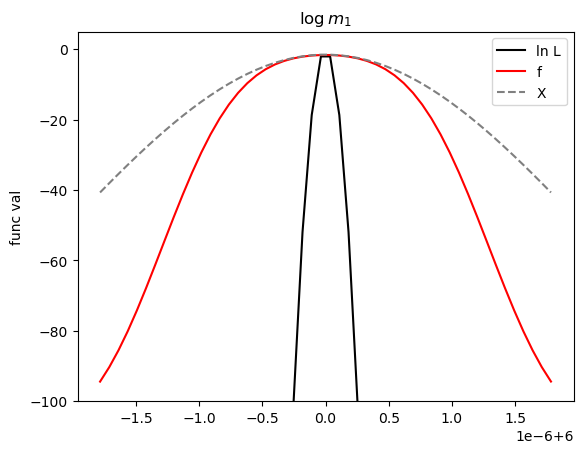

In [173]:
# NOTE: do not normalize
plt.plot(x, loglike_vals_new, c='k', label='ln L')
plt.plot(x, f_vals_fix_new, c='r',label=r'f')
plt.plot(x, X_vals_new, c='grey',linestyle='dashed', label=r'X')
plt.ylim(-100,5)
plt.legend()
plt.ylabel(r'func val')
plt.title(r'$\log m_1$')
plt.show()

In [175]:
x

array([5.99999822, 5.99999829, 5.99999836, 5.99999843, 5.99999851,
       5.99999858, 5.99999865, 5.99999873, 5.9999988 , 5.99999887,
       5.99999894, 5.99999902, 5.99999909, 5.99999916, 5.99999924,
       5.99999931, 5.99999938, 5.99999945, 5.99999953, 5.9999996 ,
       5.99999967, 5.99999975, 5.99999982, 5.99999989, 5.99999996,
       6.00000004, 6.00000011, 6.00000018, 6.00000025, 6.00000033,
       6.0000004 , 6.00000047, 6.00000055, 6.00000062, 6.00000069,
       6.00000076, 6.00000084, 6.00000091, 6.00000098, 6.00000106,
       6.00000113, 6.0000012 , 6.00000127, 6.00000135, 6.00000142,
       6.00000149, 6.00000157, 6.00000164, 6.00000171, 6.00000178])